In [1]:
import os
import pickle
import unicodedata
from collections import defaultdict

# ============================================================
# PATH
# ============================================================
train_path     = "/kaggle/input/datasets/captainviet/sign-language/dataraw/train"
label_map_path = "/kaggle/input/datasets/captainviet/sign-language/dataraw/label_mapping.pkl"

# ============================================================
# LOAD LABEL MAP + NORMALIZE
# ============================================================
with open(label_map_path, "rb") as f:
    raw_label_map = pickle.load(f)

label_map  = {unicodedata.normalize('NFC', k.strip()): v for k, v in raw_label_map.items()}
map_labels = set(label_map.keys())
print("So lop trong label map:", len(map_labels))

# ============================================================
# DEM VIDEO TRONG TRAIN
# ============================================================
video_count   = 0
folder_labels = set()
class_counts  = defaultdict(int)

for label in os.listdir(train_path):
    label_folder = os.path.join(train_path, label)
    if os.path.isdir(label_folder):
        norm_label = unicodedata.normalize('NFC', label.strip())
        folder_labels.add(norm_label)
        videos = os.listdir(label_folder)
        class_counts[norm_label] = len(videos)
        video_count += len(videos)

print("Tong so video train:", video_count)
print("So lop trong folder:", len(folder_labels))

# ============================================================
# SO SANH
# ============================================================
missing_in_map    = folder_labels - map_labels
missing_in_folder = map_labels - folder_labels

print("\nKIEM TRA LABEL")
print("Folder co, map khong co:", missing_in_map    or "Khong co")
print("Map co, folder khong co:", missing_in_folder or "Khong co")

# ============================================================
# THONG KE
# ============================================================
max_class = max(class_counts, key=class_counts.get)
min_class = min(class_counts, key=class_counts.get)

print("\nLop nhieu video nhat:", max_class, class_counts[max_class])
print("Lop it video nhat   :", min_class, class_counts[min_class])

So lop trong label map: 100
Tong so video train: 3838
So lop trong folder: 100

KIEM TRA LABEL
Folder co, map khong co: Khong co
Map co, folder khong co: Khong co

Lop nhieu video nhat: Trường học 74
Lop it video nhat   : Cách ly 6


In [2]:
import os
import cv2
import torch
import numpy as np
import pickle
import traceback
import unicodedata
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# ============================================================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ============================================================

BASE_PATH = "/kaggle/input/datasets/captainviet/sign-language/dataraw"

TRAIN_DIR = os.path.join(BASE_PATH, "train")
PKL_PATH = os.path.join(BASE_PATH, "label_mapping.pkl")


# ============================================================
# HÀM CHUẨN HÓA UNICODE
# ============================================================

def normalize_text(text):
    return unicodedata.normalize("NFC", text)


# ============================================================
# 2. CLASS DATASET
# ============================================================

class LSViT_VideoDataset(Dataset):

    def __init__(self, root_dir, pkl_path, mode='train',
                 num_frames=16, img_size=224, num_classes_test=None):

        self.root_dir = root_dir
        self.mode = mode
        self.num_frames = num_frames
        self.img_size = img_size
        self.samples = []

        # ----------------------------------------------------
        # BƯỚC 1: LOAD LABEL MAPPING
        # ----------------------------------------------------

        if not os.path.exists(pkl_path):
            raise RuntimeError(f"❌ Không tìm thấy label_mapping: {pkl_path}")

        with open(pkl_path, "rb") as f:
            full_mapping = pickle.load(f)

        all_classes = sorted(full_mapping.keys(),
                             key=lambda x: full_mapping[x])

        if num_classes_test is not None:
            self.classes = all_classes[:num_classes_test]
            print(f"⚠️ TEST MODE: {num_classes_test} classes")
        else:
            self.classes = all_classes

        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        # ----------------------------------------------------
        # BƯỚC 2: QUÉT DATASET
        # ----------------------------------------------------

        print(f"[{mode.upper()}] Đang quét dataset...")

        video_ext = [".mp4",".avi",".mov",".mkv",".MP4",".AVI",".MOV",".MKV"]

        # lấy danh sách folder thật
        real_folders = os.listdir(root_dir)

        # chuẩn hóa unicode
        normalized_folders = {
            normalize_text(f): f for f in real_folders
        }

        missing_classes = 0

        for class_name in self.classes:

            norm_class = normalize_text(class_name)

            if norm_class not in normalized_folders:
                print("⚠️ Thiếu folder:", class_name)
                missing_classes += 1
                continue

            real_folder = normalized_folders[norm_class]

            class_path = os.path.join(root_dir, real_folder)

            class_idx = self.class_to_idx[class_name]

            for file in os.listdir(class_path):

                ext = os.path.splitext(file)[1]

                if ext in video_ext:

                    video_path = os.path.join(class_path, file)

                    self.samples.append((video_path, class_idx))

        if len(self.samples) == 0:
            raise RuntimeError("❌ Không tìm thấy video")

        print("✅ Tổng video:", len(self.samples))
        print("✅ Số lớp mapping:", len(self.classes))
        print("⚠️ Lớp thiếu:", missing_classes)

        # ----------------------------------------------------
        # BƯỚC 3: TRANSFORM
        # ----------------------------------------------------

        if mode == "train":

            self.transform = transforms.Compose([
                transforms.Resize((256,256)),
                transforms.RandomCrop((img_size,img_size)),
                transforms.RandomRotation(5),
                transforms.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.1,
                    hue=0.05
                ),
                transforms.RandomApply(
                    [transforms.GaussianBlur(3)], p=0.2
                ),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485,0.456,0.406],
                    std=[0.229,0.224,0.225]
                )
            ])

        else:

            self.transform = transforms.Compose([
                transforms.Resize((img_size,img_size)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485,0.456,0.406],
                    std=[0.229,0.224,0.225]
                )
            ])

    # ========================================================
    # DATASET FUNCTIONS
    # ========================================================

    def __len__(self):
        return len(self.samples)

    def _get_frames(self, video_path):

        cap = cv2.VideoCapture(video_path)

        if not cap.isOpened():
            return torch.zeros((3,self.num_frames,self.img_size,self.img_size))

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames <= 0:
            cap.release()
            return torch.zeros((3,self.num_frames,self.img_size,self.img_size))

        # sampling frame

        if total_frames <= self.num_frames:

            indices = np.linspace(
                0,total_frames-1,self.num_frames
            ).astype(int)

        elif self.mode == "train":

            boundaries = np.linspace(
                0,total_frames-1,self.num_frames+1
            ).astype(int)

            indices = [
                np.random.randint(boundaries[i],boundaries[i+1])
                if boundaries[i] < boundaries[i+1]
                else boundaries[i]
                for i in range(self.num_frames)
            ]

        else:

            indices = np.linspace(
                0,total_frames-1,self.num_frames
            ).astype(int)

        frames = []

        for idx in indices:

            cap.set(cv2.CAP_PROP_POS_FRAMES,int(idx))
            ret,frame = cap.read()

            if not ret:

                frame_tensor = frames[-1] if frames else torch.zeros(
                    (3,self.img_size,self.img_size)
                )

            else:

                frame = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
                frame = Image.fromarray(frame)
                frame_tensor = self.transform(frame)

            frames.append(frame_tensor)

        cap.release()

        while len(frames) < self.num_frames:
            frames.append(torch.zeros((3,self.img_size,self.img_size)))

        video_tensor = torch.stack(frames[:self.num_frames])

        return video_tensor.permute(1,0,2,3)

    def __getitem__(self, idx):

        video_path,label = self.samples[idx]

        video_tensor = self._get_frames(video_path)

        return video_tensor, torch.tensor(label)


# ============================================================
# 3. TEST DATASET
# ============================================================

try:

    print("🚀 TEST DATASET")

    train_dataset = LSViT_VideoDataset(
        root_dir=TRAIN_DIR,
        pkl_path=PKL_PATH,
        mode="train",
        num_frames=16,
        num_classes_test=None
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=8,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    inputs,labels = next(iter(train_loader))

    print("\n=========================")
    print("✅ DATASET OK")
    print("=========================")

    print("Total videos:",len(train_dataset))
    print("Batch shape:",inputs.shape)
    print("Labels:",labels.tolist())
    print("Classes:",train_dataset.classes[:10])

except Exception:

    print("❌ ERROR")
    traceback.print_exc()

🚀 TEST DATASET
[TRAIN] Đang quét dataset...
✅ Tổng video: 3838
✅ Số lớp mapping: 100
⚠️ Lớp thiếu: 0

✅ DATASET OK
Total videos: 3838
Batch shape: torch.Size([8, 3, 16, 224, 224])
Labels: [94, 66, 0, 20, 32, 41, 99, 74]
Classes: ['An ủi', 'Áp dụng', 'Ăn', 'Ăn mừng', 'Ban ngày', 'Ban đêm', 'Bàn tay', 'Băn khoăn', 'Bạn thân', 'Bế mạc']


In [3]:
import torch
import torch.nn as nn
import torchvision.models as models

# ============================================================
# KIẾN TRÚC MÔ HÌNH: LS-ViT (ULTIMATE OPTIMIZED)
# ============================================================
class LSViT(nn.Module):
    def __init__(self, num_classes=100, hidden_dim=512, num_heads=8, num_layers=4, dropout=0.3, num_frames=16):
        super(LSViT, self).__init__()

        self.num_frames = num_frames

        # -------------------------------------------------------
        # 1. SPATIAL FEATURE EXTRACTOR
        # -------------------------------------------------------
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        for param in resnet.parameters():
            param.requires_grad = False

        for param in resnet.layer3.parameters():
            param.requires_grad = True
        for param in resnet.layer4.parameters():
            param.requires_grad = True

        self.feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
        resnet_out_dim = 512

        # [ULTIMATE FIX 1] Dùng LayerNorm thay vì BatchNorm1d để tương thích AMP
        self.projector = nn.Sequential(
            nn.Linear(resnet_out_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        # -------------------------------------------------------
        # 2. TEMPORAL TRANSFORMER
        # -------------------------------------------------------

        # [ULTIMATE FIX 3] Khởi tạo CLS token với Truncated Normal (std=0.02)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, hidden_dim))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # [ULTIMATE FIX 2] Positional encoding với randn * 0.02
        self.positional_encoding = nn.Parameter(torch.randn(1, num_frames + 1, hidden_dim) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # -------------------------------------------------------
        # 3. CLASSIFICATION HEAD
        # -------------------------------------------------------
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.projector.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        B, C, T, H, W = x.shape

        # Trích xuất đặc trưng từng frame
        x = x.permute(0, 2, 1, 3, 4).reshape(B * T, C, H, W)
        features = self.feature_extractor(x)
        features = features.view(features.size(0), -1)
        features = self.projector(features)
        features = features.view(B, T, -1)

        # Thêm CLS token
        cls_tokens = self.cls_token.expand(B, -1, -1)
        features = torch.cat([cls_tokens, features], dim=1)

        # Cộng positional encoding
        features = features + self.positional_encoding[:, :T + 1, :]

        # Transformer
        transformer_out = self.transformer(features)

        # Lấy CLS token làm đại diện
        global_feature = transformer_out[:, 0, :]

        # Phân loại
        return self.classifier(global_feature)


# ============================================================
# CHẠY THỬ MÔ HÌNH VỚI FULL CLASS
# ============================================================
print("🚀 Đang khởi tạo mô hình LS-ViT (Ultimate Optimized)...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# [FIX] Dùng globals() thay locals(), và đúng tên biến train_dataset từ cell 2
if 'train_dataset' in globals():
    NUM_CLASSES = len(train_dataset.classes)
    print(f"👉 Nhận diện được {NUM_CLASSES} lớp từ dữ liệu.")
else:
    NUM_CLASSES = 100
    print(f"⚠️ Dùng mặc định {NUM_CLASSES} lớp.")

# Khởi tạo mô hình và đẩy lên GPU/CPU
model = LSViT(num_classes=NUM_CLASSES, num_frames=16).to(device)

# Đếm số tham số
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"Tổng tham số      : {total_params:,}")
print(f"Tham số huấn luyện: {trainable_params:,}")
print(f"Tham số đóng băng : {frozen_params:,}")

# Kiểm tra forward pass
dummy_input = torch.randn(8, 3, 16, 224, 224).to(device)
output = model(dummy_input)

# [NEW] Kiểm tra output shape
print(f"\nInput shape : {dummy_input.shape}")
print(f"Output shape: {output.shape}")
assert output.shape == (8, NUM_CLASSES), "❌ Output shape sai!"

print("\n" + "="*40)
print(f"✅ KIỂM TRA THÀNH CÔNG TRÊN THIẾT BỊ: {device.type.upper()}")
print("="*40)
print("Mô hình đã đạt trạng thái tối ưu nhất để train với AMP!")

🚀 Đang khởi tạo mô hình LS-ViT (Ultimate Optimized)...
👉 Nhận diện được 100 lớp từ dữ liệu.
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Tổng tham số      : 24,216,996
Tham số huấn luyện: 23,533,924
Tham số đóng băng : 683,072

Input shape : torch.Size([8, 3, 16, 224, 224])
Output shape: torch.Size([8, 100])

✅ KIỂM TRA THÀNH CÔNG TRÊN THIẾT BỊ: CUDA
Mô hình đã đạt trạng thái tối ưu nhất để train với AMP!


In [4]:
import torch
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np

print("⏳ Đang chuẩn bị chia dữ liệu Train / Val / Test...")

# ============================================================
# 1. LOAD DATASET
# ============================================================
full_dataset = LSViT_VideoDataset(
    root_dir=TRAIN_DIR,
    pkl_path=PKL_PATH,
    mode='train',
    num_frames=16,
    num_classes_test=None
)

# ============================================================
# 2. LẤY LABEL — truy cập trực tiếp samples, không decode video
# ============================================================
labels  = [label for _, label in full_dataset.samples]
indices = np.arange(len(full_dataset))

# ============================================================
# 3. CHIA TRAIN(64%) / VAL(16%) / TEST(20%)
# ============================================================
# Bước 1: tách 20% test
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

# Bước 2: tách 16% val từ 80% còn lại (0.20 * 80% = 16% tổng)
train_labels_tmp = [labels[i] for i in train_idx]
train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.20,
    stratify=train_labels_tmp,
    random_state=42
)

# ============================================================
# 4. KIỂM TRA PHÂN PHỐI
# ============================================================
train_counts = Counter([labels[i] for i in train_idx])
val_counts   = Counter([labels[i] for i in val_idx])
test_counts  = Counter([labels[i] for i in test_idx])

min_train = min(train_counts, key=train_counts.get)
print(f"⚠️  Lớp ít nhất trong Train: {min_train} — {train_counts[min_train]} video")

# ============================================================
# 5. TẠO SUBSET — dùng tên subset để không conflict train_dataset
# ============================================================
train_subset = Subset(full_dataset, train_idx)

# Val/Test dùng mode='val' để tránh augmentation
val_dataset_base  = LSViT_VideoDataset(
    root_dir=TRAIN_DIR, pkl_path=PKL_PATH,
    mode='val', num_frames=16, num_classes_test=None
)
test_dataset_base = LSViT_VideoDataset(
    root_dir=TRAIN_DIR, pkl_path=PKL_PATH,
    mode='test', num_frames=16, num_classes_test=None
)
val_subset  = Subset(val_dataset_base,  val_idx)
test_subset = Subset(test_dataset_base, test_idx)

# ============================================================
# 6. DATALOADER
# ============================================================
batch_size  = 8
num_workers = 2
pin_memory  = torch.cuda.is_available()

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)
test_loader  = DataLoader(test_subset,  batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

# ============================================================
# TỔNG KẾT
# ============================================================
total = len(full_dataset)
print("\n" + "="*50)
print("✅ CHIA DỮ LIỆU THÀNH CÔNG (64 / 16 / 20)")
print("="*50)
print(f"Tổng video  : {total}")
print(f"Train       : {len(train_subset)} ({len(train_subset)/total*100:.1f}%)")
print(f"Validation  : {len(val_subset)}   ({len(val_subset)/total*100:.1f}%)")
print(f"Test        : {len(test_subset)}  ({len(test_subset)/total*100:.1f}%)")
print("="*50)

⏳ Đang chuẩn bị chia dữ liệu Train / Val / Test...
[TRAIN] Đang quét dataset...
✅ Tổng video: 3838
✅ Số lớp mapping: 100
⚠️ Lớp thiếu: 0
⚠️  Lớp ít nhất trong Train: 30 — 4 video
[VAL] Đang quét dataset...
✅ Tổng video: 3838
✅ Số lớp mapping: 100
⚠️ Lớp thiếu: 0
[TEST] Đang quét dataset...
✅ Tổng video: 3838
✅ Số lớp mapping: 100
⚠️ Lớp thiếu: 0

✅ CHIA DỮ LIỆU THÀNH CÔNG (64 / 16 / 20)
Tổng video  : 3838
Train       : 2456 (64.0%)
Validation  : 614   (16.0%)
Test        : 768  (20.0%)


In [5]:
import os
for f in ["lsvit_last.pth", "lsvit_best.pth", "lsvit_history.pkl"]:
    path = f"/kaggle/working/{f}"
    if os.path.exists(path):
        os.remove(path)
        print(f"🗑️ Đã xóa: {path}")

In [6]:
import os
import time
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import GradScaler          # [FIX 3] import mới
from tqdm.auto import tqdm
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

# ============================================================
# LOSS + OPTIMIZER
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW([
    {'params': model.feature_extractor.parameters(), 'lr': 1e-5},
    {'params': model.projector.parameters(),         'lr': 1e-4},
    {'params': model.transformer.parameters(),       'lr': 1e-4},
    {'params': model.classifier.parameters(),        'lr': 1e-4},
], weight_decay=1e-2)

NUM_EPOCHS = 30

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

# ============================================================
# EARLY STOPPING
# ============================================================
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, mode='max'):
        self.patience  = patience
        self.min_delta = min_delta
        self.mode      = mode
        self.counter   = 0
        self.best      = None
        self.stop      = False

    def step(self, metric):
        if self.best is None:
            self.best = metric
            return
        improved = (metric > self.best + self.min_delta) if self.mode == 'max' \
                   else (metric < self.best - self.min_delta)
        if improved:
            self.best    = metric
            self.counter = 0
        else:
            self.counter += 1
            print(f"⏳ EarlyStopping: {self.counter}/{self.patience} (best={self.best:.4f})")
            if self.counter >= self.patience:
                self.stop = True

# ============================================================
# METRICS
# ============================================================
def compute_metrics(y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return {'acc': acc, 'precision': prec, 'recall': rec, 'f1': f1}

# ============================================================
# TRAIN FUNCTION
# ============================================================
def train_and_validate(model, train_loader, val_loader,
                       criterion, optimizer, scheduler,
                       num_epochs=30,
                       device='cuda',
                       save_dir='/kaggle/working',
                       experiment_name='lsvit',
                       reset_training=False,
                       early_stopping_patience=5,
                       early_stopping_min_delta=1e-4):

    os.makedirs(save_dir, exist_ok=True)

    best_path    = os.path.join(save_dir, f"{experiment_name}_best.pth")
    last_path    = os.path.join(save_dir, f"{experiment_name}_last.pth")
    history_path = os.path.join(save_dir, f"{experiment_name}_history.pkl")

    # [FIX 6] Chuẩn hóa device trước khi kiểm tra
    device  = torch.device(device) if isinstance(device, str) else device
    is_cuda = device.type == 'cuda'

    # [FIX 3] GradScaler API mới
    scaler = GradScaler('cuda' if is_cuda else 'cpu', enabled=is_cuda)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'train_prec': [], 'val_prec': [],
        'train_rec':  [], 'val_rec':  [],
        'train_f1':   [], 'val_f1':   [],
    }

    best_val_f1 = 0.0
    start_epoch = 0

    early_stopper = EarlyStopping(
        patience=early_stopping_patience,
        min_delta=early_stopping_min_delta,
        mode='max'
    )

    if reset_training:
        print("⚠️  RESET TRAINING FROM SCRATCH")
        for p in [last_path, history_path]:
            if os.path.exists(p): os.remove(p)

    if os.path.exists(last_path) and not reset_training:
        print("🔄 Resume training from checkpoint")
        checkpoint = torch.load(last_path, map_location=device)
        model.load_state_dict(checkpoint['model'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        scheduler.load_state_dict(checkpoint['scheduler'])
        start_epoch         = checkpoint['epoch']
        best_val_f1         = checkpoint['best_val_f1']
        early_stopper.best    = checkpoint.get('es_best', best_val_f1)
        early_stopper.counter = checkpoint.get('es_counter', 0)
        if os.path.exists(history_path):
            with open(history_path, "rb") as f:
                history = pickle.load(f)
        print(f"Resumed from epoch {start_epoch} | best val F1: {best_val_f1:.4f}")

    print("\n🚀 START TRAINING\n")
    print(f"{'Epoch':<7} {'T-Loss':<9} {'T-Acc':<8} {'T-Prec':<9} "
          f"{'T-Rec':<8} {'T-F1':<8} | "
          f"{'V-Loss':<9} {'V-Acc':<8} {'V-Prec':<9} "
          f"{'V-Rec':<8} {'V-F1':<8}")
    print("-" * 100)

    for epoch in range(start_epoch, num_epochs):

        start_time = time.time()

        # ─── TRAIN ───
        model.train()
        train_loss   = 0.0
        n_train      = 0          # [FIX 1] đếm sample thực
        y_true_train = []
        y_pred_train = []

        for inputs, labels in tqdm(train_loader,
                                   desc=f"Epoch {epoch+1}/{num_epochs} [Train]",
                                   leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.autocast(device_type='cuda' if is_cuda else 'cpu', enabled=is_cuda):
                outputs = model(inputs)
                loss    = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item() * inputs.size(0)
            n_train    += inputs.size(0)                  # [FIX 1]
            preds = torch.argmax(outputs, dim=1)
            y_true_train.extend(labels.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())

        train_loss /= n_train                             # [FIX 1]
        train_m     = compute_metrics(y_true_train, y_pred_train)

        # ─── VALIDATION ───
        model.eval()
        val_loss   = 0.0
        n_val      = 0            # [FIX 2] đếm sample thực
        y_true_val = []
        y_pred_val = []

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader,
                                       desc=f"Epoch {epoch+1}/{num_epochs} [Val]",
                                       leave=False):
                inputs = inputs.to(device)
                labels = labels.to(device)

                with torch.autocast(device_type='cuda' if is_cuda else 'cpu', enabled=is_cuda):
                    outputs = model(inputs)
                    loss    = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                n_val    += inputs.size(0)                # [FIX 2]
                preds = torch.argmax(outputs, dim=1)
                y_true_val.extend(labels.cpu().numpy())
                y_pred_val.extend(preds.cpu().numpy())

        val_loss /= n_val                                 # [FIX 2]
        val_m     = compute_metrics(y_true_val, y_pred_val)

        scheduler.step()
        elapsed = time.time() - start_time

        # ─── HISTORY ───
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_m['acc'])
        history['val_acc'].append(val_m['acc'])
        history['train_prec'].append(train_m['precision'])
        history['val_prec'].append(val_m['precision'])
        history['train_rec'].append(train_m['recall'])
        history['val_rec'].append(val_m['recall'])
        history['train_f1'].append(train_m['f1'])
        history['val_f1'].append(val_m['f1'])

        with open(history_path, "wb") as f:
            pickle.dump(history, f)

        # ─── PRINT ───
        print(
            f"{epoch+1:<7} "
            f"{train_loss:<9.4f} {train_m['acc']:<8.4f} {train_m['precision']:<9.4f} "
            f"{train_m['recall']:<8.4f} {train_m['f1']:<8.4f} | "
            f"{val_loss:<9.4f} {val_m['acc']:<8.4f} {val_m['precision']:<9.4f} "
            f"{val_m['recall']:<8.4f} {val_m['f1']:<8.4f}  "
            f"⏱ {elapsed:.1f}s"
        )

        # ─── SAVE BEST ───
        if val_m['f1'] > best_val_f1:
            best_val_f1 = val_m['f1']
            torch.save(model.state_dict(), best_path)
            print("  ✅ Saved BEST model")

        # ─── EARLY STOPPING step trước ───       [FIX 5]
        early_stopper.step(val_m['f1'])

        # ─── SAVE LAST — sau ES step để counter chính xác ─── [FIX 5]
        torch.save({
            'epoch':       epoch + 1,
            'model':       model.state_dict(),
            'optimizer':   optimizer.state_dict(),
            'scheduler':   scheduler.state_dict(),
            'best_val_f1': best_val_f1,
            'es_best':     early_stopper.best,
            'es_counter':  early_stopper.counter,
        }, last_path)

        if early_stopper.stop:
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
            break

    print(f"\n🏆 Best Val F1: {best_val_f1:.4f}")
    return history


# ============================================================
# RUN TRAIN
# ============================================================
history = train_and_validate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=NUM_EPOCHS,
    device=device,
    save_dir='/kaggle/working',
    experiment_name='lsvit',
    reset_training= False,
    early_stopping_patience=5,
    early_stopping_min_delta=1e-4,
)


🚀 START TRAINING

Epoch   T-Loss    T-Acc    T-Prec    T-Rec    T-F1     | V-Loss    V-Acc    V-Prec    V-Rec    V-F1    
----------------------------------------------------------------------------------------------------


Epoch 1/30 [Train]:   0%|          | 0/307 [00:00<?, ?it/s]

Epoch 1/30 [Val]:   0%|          | 0/77 [00:00<?, ?it/s]

1       4.6066    0.0244   0.0160    0.0156   0.0126   | 4.2622    0.0326   0.0007    0.0200   0.0013    ⏱ 291.7s
  ✅ Saved BEST model


Epoch 2/30 [Train]:   0%|          | 0/307 [00:00<?, ?it/s]

...

Epoch 29/30 [Val]:   0%|          | 0/77 [00:00<?, ?it/s]

29      1.1086    0.9389   0.9348    0.8782   0.8908   | 1.2872    0.8648   0.7576    0.7632   0.7505    ⏱ 290.5s
⏳ EarlyStopping: 1/5 (best=0.7727)


Epoch 30/30 [Train]:   0%|          | 0/307 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/77 [00:00<?, ?it/s]

30      1.0874    0.9524   0.9407    0.9018   0.9139   | 1.2854    0.8697   0.7689    0.7747   0.7611    ⏱ 288.2s
⏳ EarlyStopping: 2/5 (best=0.7727)

🏆 Best Val F1: 0.7727


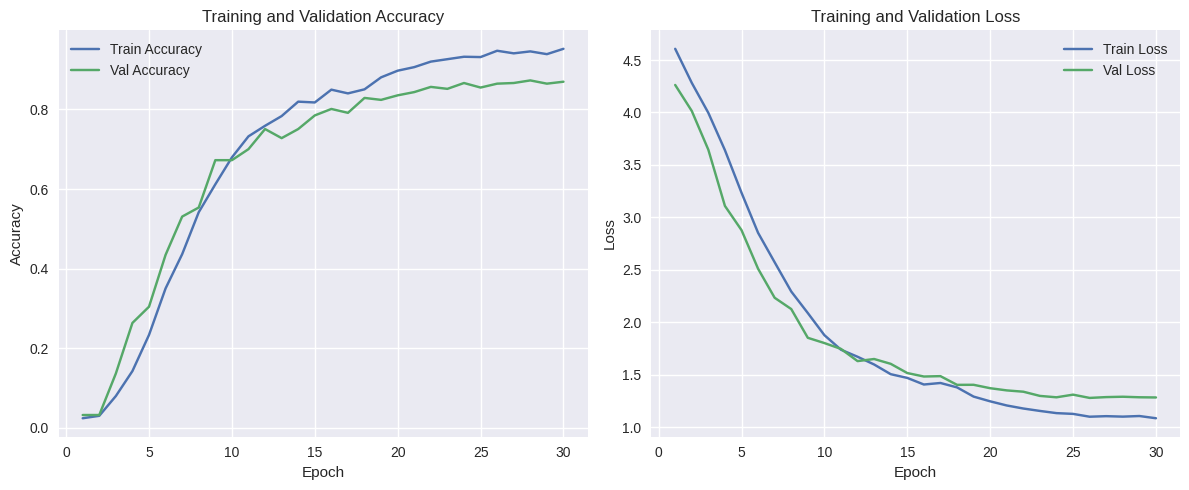

/tmp/ipykernel_23/1072139041.py:97: UserWarning: Glyph 7911 (\N{LATIN SMALL LETTER U WITH HOOK ABOVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/1072139041.py:97: UserWarning: Glyph 7909 (\N{LATIN SMALL LETTER U WITH DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/1072139041.py:97: UserWarning: Glyph 7915 (\N{LATIN SMALL LETTER U WITH HORN AND GRAVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/1072139041.py:97: UserWarning: Glyph 7841 (\N{LATIN SMALL LETTER A WITH DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/1072139041.py:97: UserWarning: Glyph 7871 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_23/1072139041.py:97: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/t

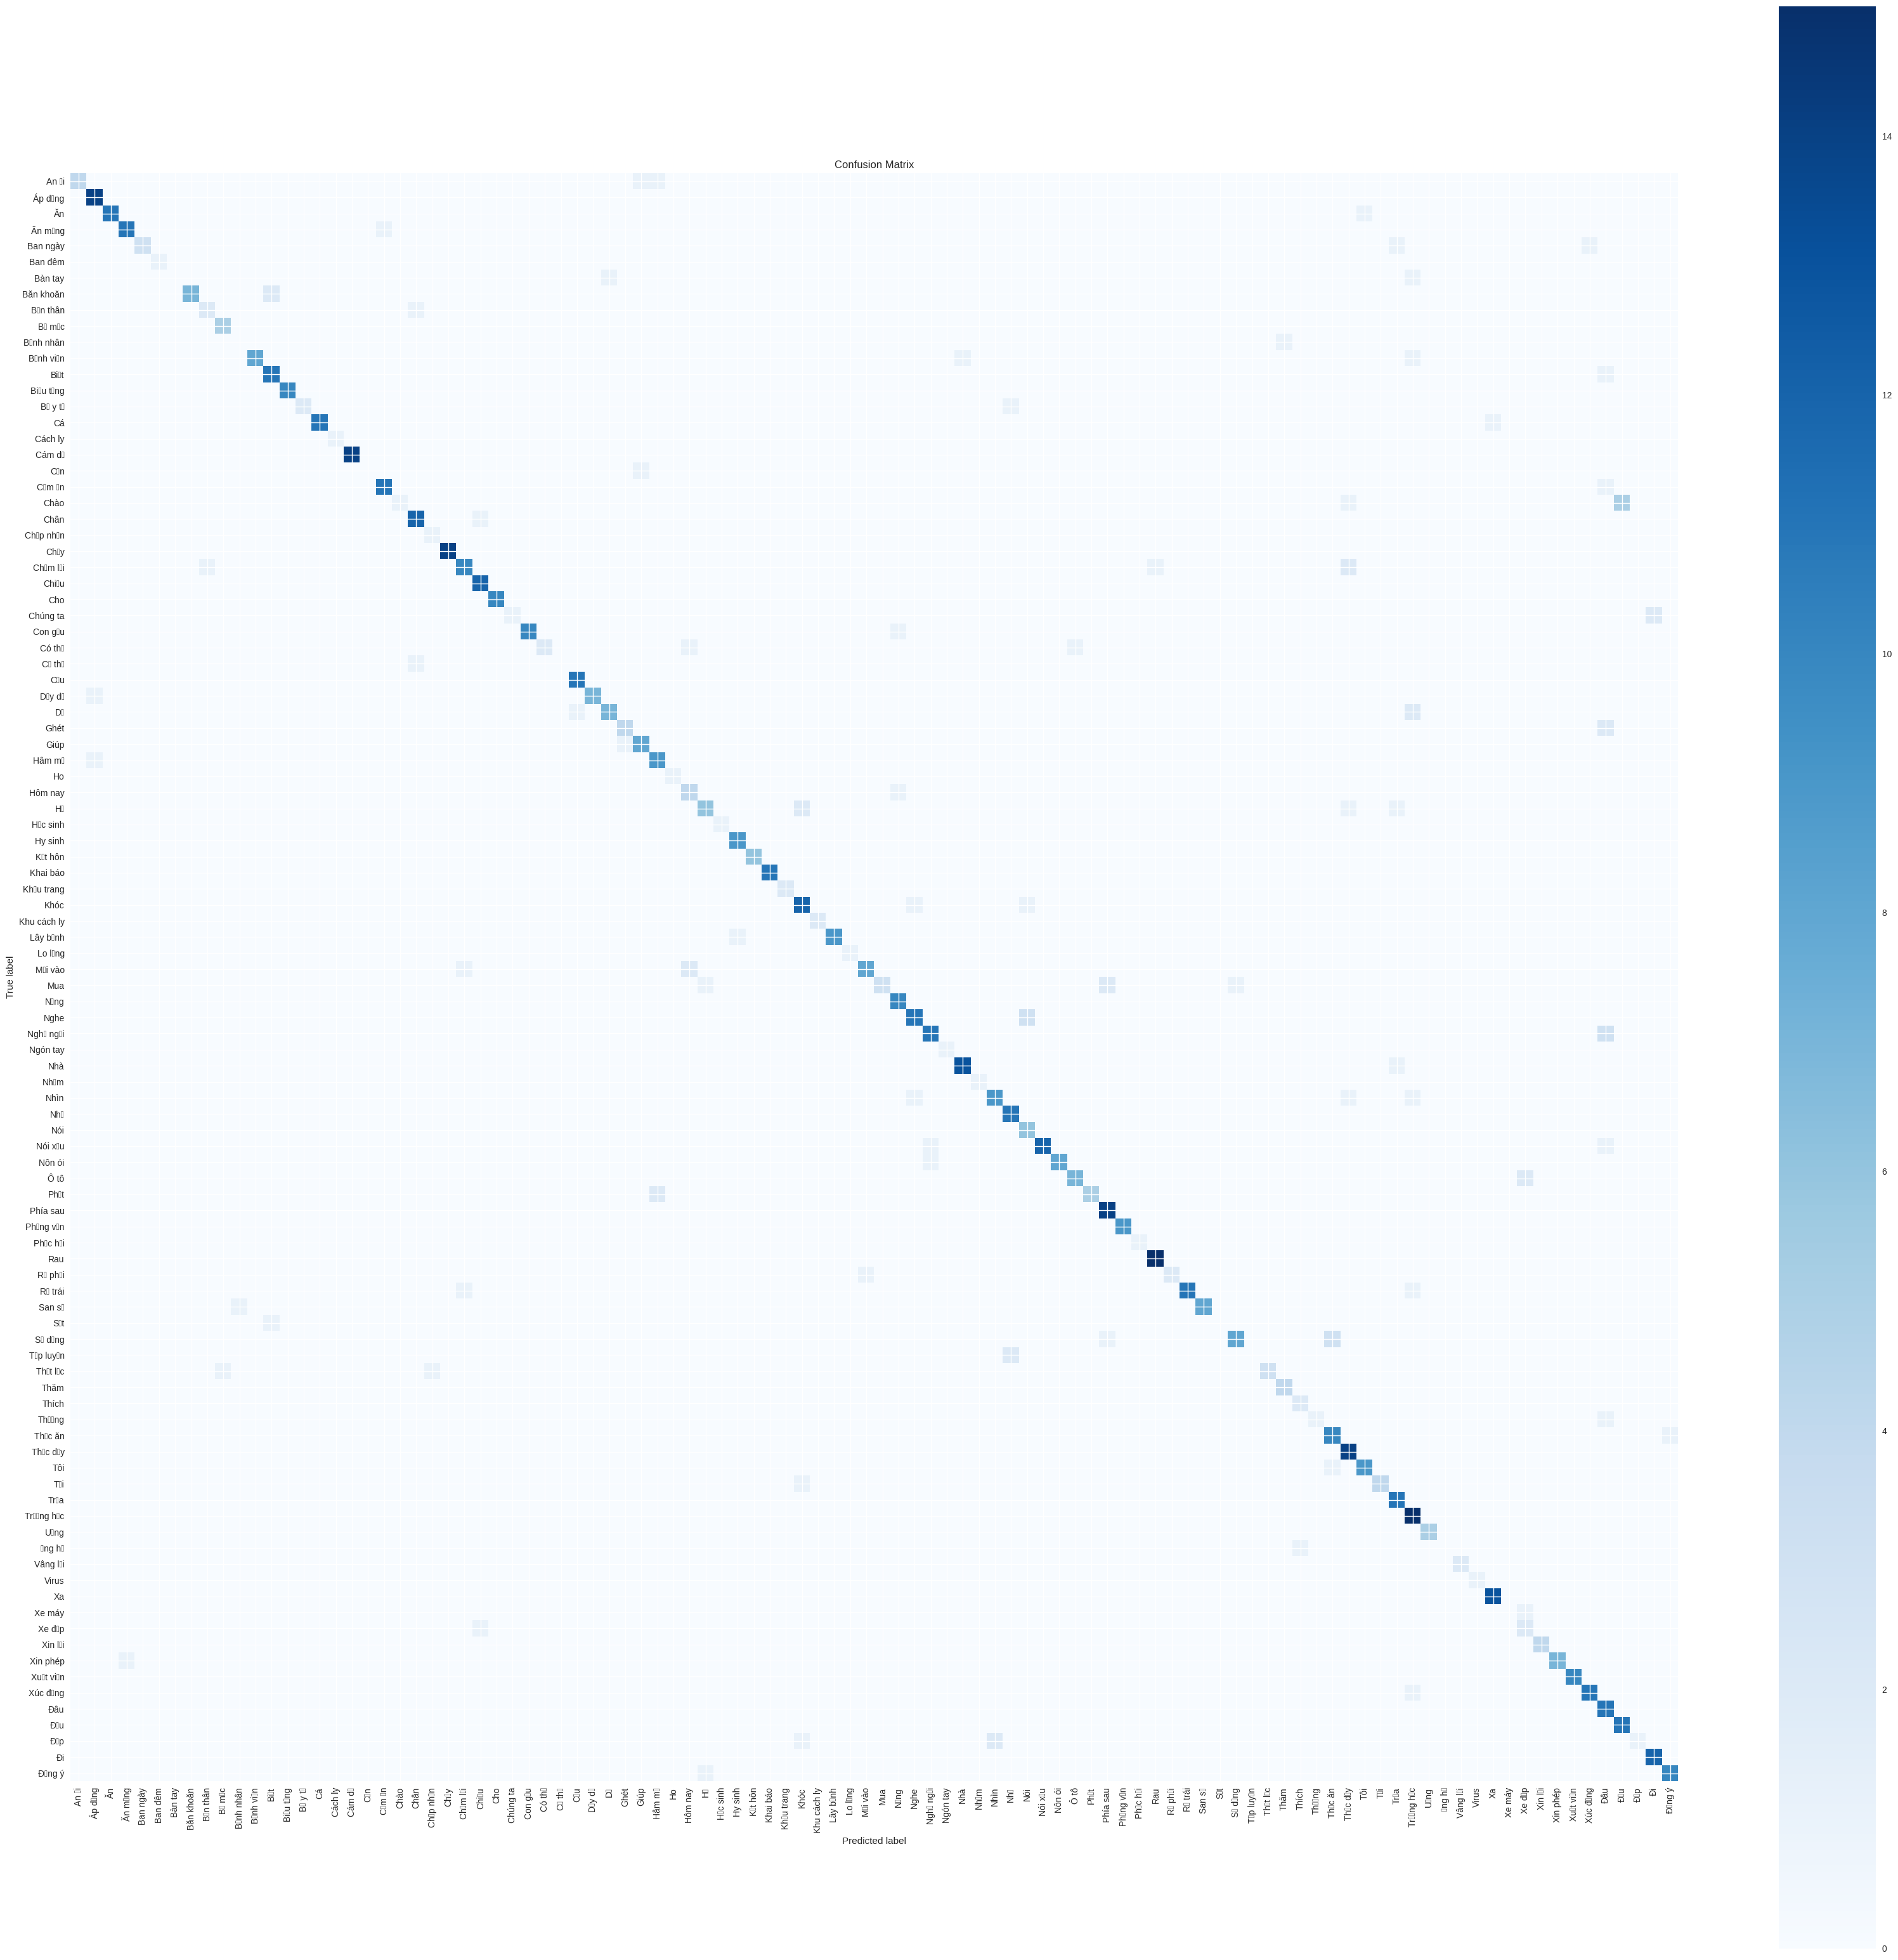

✅ Đã lưu: /kaggle/working/confusion_matrix.csv
✅ Đã lưu: /kaggle/working/per_class_accuracy.csv
✅ Đã lưu: /kaggle/working/predictions.csv

📊 Overall Accuracy : 0.8672 (86.72%)
📄 Total samples    : 768
📂 Files saved to   : /kaggle/working/


In [7]:
import pickle
import matplotlib.pyplot as plt
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

history_path    = "/kaggle/working/lsvit_history.pkl"
best_model_path = "/kaggle/working/lsvit_best.pth"

# ============================================================
# LOAD HISTORY
# ============================================================
with open(history_path, "rb") as f:
    history = pickle.load(f)

epochs = range(1, len(history["train_loss"]) + 1)

# [FIX 5] style an toàn hơn
try:
    plt.style.use("seaborn-v0_8")
except OSError:
    plt.style.use("seaborn")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs, history["train_acc"],  label="Train Accuracy")
axes[0].plot(epochs, history["val_acc"],    label="Val Accuracy")
axes[0].set_title("Training and Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, history["train_loss"], label="Train Loss")
axes[1].plot(epochs, history["val_loss"],   label="Val Loss")
axes[1].set_title("Training and Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# COLLECT PREDICTIONS
# ============================================================

# [FIX 2] weights_only=True tránh warning PyTorch 2.6+
model.load_state_dict(torch.load(best_model_path,
                                  map_location=device,
                                  weights_only=True))
model.eval()

y_true, y_pred = [], []

# [NOTE] Dùng test_loader cho đánh giá cuối — đổi thành val_loader nếu cố ý
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        preds   = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Lấy class names
try:
    class_names = full_dataset.classes
except Exception:
    class_names = [str(i) for i in range(max(y_true) + 1)]

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm      = confusion_matrix(y_true, y_pred)
n_class = len(class_names)

# [FIX 3] Size lớn hơn + tắt values khi nhiều class
fig_size    = max(10, n_class // 3)
show_values = n_class <= 30

fig, ax = plt.subplots(figsize=(fig_size, fig_size - 2))

# [FIX 1] Truyền display_labels
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=class_names).plot(
    cmap="Blues",
    xticks_rotation=90,
    colorbar=True,
    ax=ax,
    include_values=show_values
)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ============================================================
# XUẤT CSV 1: CONFUSION MATRIX ĐẦY ĐỦ
# ============================================================
cm_df = pd.DataFrame(
    cm,
    index=[f"True_{class_names[i]}"   for i in range(n_class)],
    columns=[f"Pred_{class_names[i]}" for i in range(n_class)]
)
cm_df.to_csv("/kaggle/working/confusion_matrix.csv")
print("✅ Đã lưu: /kaggle/working/confusion_matrix.csv")

# ============================================================
# XUẤT CSV 2: PER-CLASS ACCURACY
# ============================================================
per_class_acc = {
    c: np.mean(y_pred[y_true == c] == c)
    for c in range(n_class)
    if np.sum(y_true == c) > 0
}

acc_df = pd.DataFrame([
    {
        "class_index": c,
        "class_name":  class_names[c],
        "accuracy":    round(per_class_acc[c], 4),
        "samples":     int(np.sum(y_true == c)),
        "correct":     int(np.sum((y_true == c) & (y_pred == c))),
        "wrong":       int(np.sum((y_true == c) & (y_pred != c))),
    }
    for c in sorted(per_class_acc, key=per_class_acc.get, reverse=True)
])
acc_df.to_csv("/kaggle/working/per_class_accuracy.csv", index=False)
print("✅ Đã lưu: /kaggle/working/per_class_accuracy.csv")

# ============================================================
# XUẤT CSV 3: PREDICTION CHI TIẾT TỪNG MẪU
# ============================================================
pred_df = pd.DataFrame({
    "true_index": y_true,
    "true_label": [class_names[i] for i in y_true],
    "pred_index": y_pred,
    "pred_label": [class_names[i] for i in y_pred],
    "correct":    (y_true == y_pred).astype(int)
})
pred_df.to_csv("/kaggle/working/predictions.csv", index=False)
print("✅ Đã lưu: /kaggle/working/predictions.csv")

# ============================================================
# TỔNG KẾT
# ============================================================
overall_acc = np.mean(y_true == y_pred)
print(f"\n📊 Overall Accuracy : {overall_acc:.4f} ({overall_acc:.2%})")
print(f"📄 Total samples    : {len(y_true)}")
print(f"📂 Files saved to   : /kaggle/working/")